First 5 Rows:
   CustomerID  Age  Income  AnnualSpending  PurchaseFrequency
0           1   25   30000            1500                 15
1           2   45   80000            5000                 10
2           3   30   45000            3000                 20
3           4   35   60000            7000                 25
4           5   50   90000            2000                  8

Missing Values:
CustomerID           0
Age                  0
Income               0
AnnualSpending       0
PurchaseFrequency    0
dtype: int64


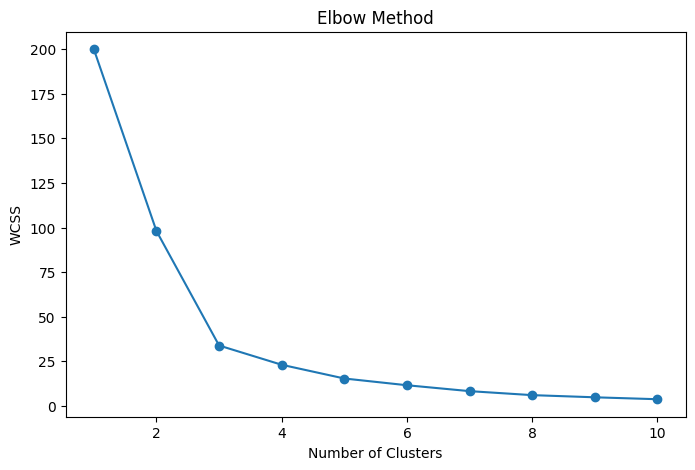


Clustered Data:
   CustomerID  Age  Income  AnnualSpending  PurchaseFrequency  Cluster
0           1   25   30000            1500                 15        3
1           2   45   80000            5000                 10        2
2           3   30   45000            3000                 20        1
3           4   35   60000            7000                 25        0
4           5   50   90000            2000                  8        2

Customers in Each Cluster:
Cluster
2    14
0    13
1    12
3    11
Name: count, dtype: int64

Cluster Summary:
         CustomerID        Age        Income  AnnualSpending  \
Cluster                                                        
0         26.615385  37.846154  69692.307692     6584.615385   
1         23.750000  30.083333  49916.666667     3733.333333   
2         26.285714  49.142857  90214.285714     3064.285714   
3         25.090909  24.818182  31636.363636     1590.909091   

         PurchaseFrequency  
Cluster                     
0 

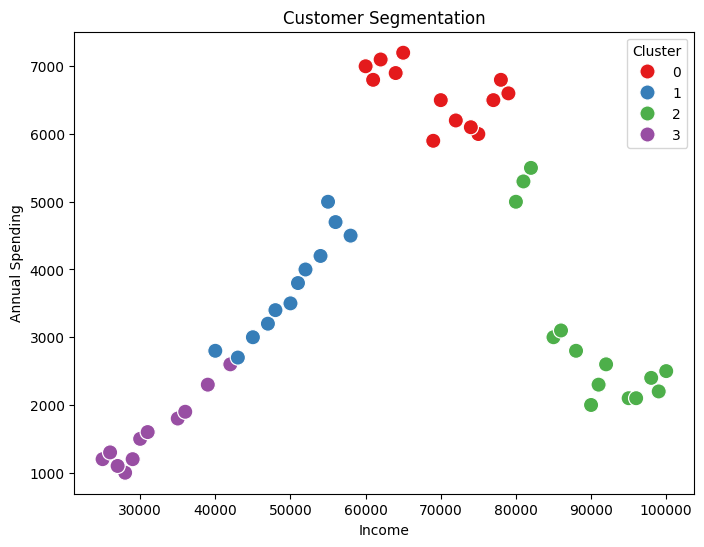


Customer_Segments.csv saved successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("customer.csv")

print("First 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

X = df[['Age', 'Income', 'AnnualSpending', 'PurchaseFrequency']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nClustered Data:")
print(df.head())

print("\nCustomers in Each Cluster:")
print(df['Cluster'].value_counts())

print("\nCluster Summary:")
print(df.groupby('Cluster').mean())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Income',
    y='AnnualSpending',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=120
)
plt.title('Customer Segmentation')
plt.xlabel('Income')
plt.ylabel('Annual Spending')
plt.show()

df.to_csv("Customer_Segments.csv", index=False)
print("\nCustomer_Segments.csv saved successfully!")